In [11]:
import numpy as np
import networkx as nx
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.decomposition import PCA

# DP algorithms

In [9]:
def random_projection(A, m , epsilon, delta):
    """
    Algorithm 1 from: https://arxiv.org/pdf/1307.0475
    """

    n = A.shape[0]
    variance = 1/epsilon * np.sqrt(10*(epsilon + np.log(1/(2*delta)))*np.log(n/delta))
    P = np.random.normal(0, 1/np.sqrt(m), size=(A.shape[0], m))
    Q = np.random.normal(0, np.sqrt(variance), size=(A.shape[0], m) )

    return A @ P + Q


In [3]:
def edge_randomization(A, epsilon):
    """
    Algorithm 3 from: https://arxiv.org/pdf/2108.06504
    or 
    Algorithm 1 from: https://ceur-ws.org/Vol-1330/paper-39.pdf
    """

    # Convert epsilon to s
    if epsilon < np.log(2):
        raise Exception("Epsilon value is too small, need to be at least ln(2)")
    
    s = 2/np.exp(epsilon)

    # Create A_perturbed
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1-s)
            if x == 1:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
            else:
                y = np.random.binomial(n=1, p=0.5)
                A_perturbed[i,j] = y
                A_perturbed[j,i] = y

    return A_perturbed


In [4]:
def lapgraph(A, epsilon):
    """
    Algorithm 4 from: https://arxiv.org/pdf/2108.06504
    """

    # Distribute privacy budget to 2 steps: 
    # + Adding Laplace noise to the A matrix
    # + Keeping the top cells within the perturbed matrix

    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    # Get DP edge count
    T = int(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1)) # Laplace noise may not be suitable for count statistics

    # Get A_perturbed with Laplace noise
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            A_perturbed[i,j] = A[i,j] + np.random.laplace(scale=1/epsilon_2)

    # Get the indices of the top T cells
    top_indices = np.unravel_index(np.argpartition(A_perturbed.flatten(), -T)[-T:], A.shape)

    # Reset all cells to 0 and set only cells in top_indices to 1
    A_perturbed = np.zeros(A.shape)
    A_perturbed[top_indices] = 1
    
    return A_perturbed + A_perturbed.T

In [5]:
def edge_flip(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed

In [59]:
def deepwalk_laplace_svd(A, embedding_dim, walk_length, epsilon, take_log=False):
    """
    DP DeepWalk with laplace noise and factorization by SVD
    """

    D_inversed = torch.diag(torch.sum(torch.tensor(A), dim=1)**-1)
    
    Z = torch.zeros(A.shape).double()
    power_matrix = torch.eye(A.shape[0]).double()
    base_matrix = D_inversed @ A
    for _ in range(walk_length):
        power_matrix = power_matrix @ base_matrix
        Z += power_matrix

    Z = Z/walk_length

    # Add laplace noise to Z
    Z = Z + torch.distributions.Laplace(loc=0, scale=2/epsilon).sample(sample_shape=Z.shape)

    if take_log:
        Z = torch.log(Z)
    
    # Use SVD to factorize
    U, S, _ = torch.linalg.svd(Z, full_matrices=False)

    X = U[:, :embedding_dim] @ torch.sqrt(torch.diag(S[:embedding_dim]))
    return X

# Experiments

In [31]:
np.random.seed(0)

In [32]:
sizes = [300, 300, 300]
probs = [
    [0.8, 0.4, 0.4],
    [0.4, 0.8, 0.4],
    [0.4, 0.4, 0.8]
]

# Generate the SBM graph
G = nx.stochastic_block_model(sizes, probs, seed=0)
A = nx.to_numpy_array(G)

In [56]:
np.logspace(-2, 3, num=16)

array([1.00000000e-02, 2.15443469e-02, 4.64158883e-02, 1.00000000e-01,
       2.15443469e-01, 4.64158883e-01, 1.00000000e+00, 2.15443469e+00,
       4.64158883e+00, 1.00000000e+01, 2.15443469e+01, 4.64158883e+01,
       1.00000000e+02, 2.15443469e+02, 4.64158883e+02, 1.00000000e+03])

In [60]:
# Get the true labels from the SBM
true_labels = []
for i, size in enumerate(sizes):
    true_labels.extend([i] * size)

# Define epsilon values to test
epsilon_values = np.array(range(1, 21, 2))/10#[0.1, 0.7, 1.0, 2.0, 5.0, 10.0]
epsilon_values = np.logspace(-2, 3, num=16) 

# Initialize results storage
results = {
    'Original': [],
    'Edge Randomization': [],
    'LapGraph': [],
    'Edge Flip': [],
    'DeepWalk Laplace SVD': [],
    'Random Projection': []
}

# Test each epsilon value
for epsilon in epsilon_values:
    print(f"Testing epsilon = {epsilon}")
    
    # Original matrix (no perturbation)
    spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
    cluster_labels = spectral_clustering.fit_predict(A)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Original'].append(nmi_score)
    
    # Random Projection
    A_rp = random_projection(A, 100, epsilon=epsilon, delta=0.01)
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(A_rp)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Random Projection'].append(nmi_score)

    # Edge Randomization
    if epsilon >= np.log(2):
        A_er = edge_randomization(A, epsilon)
        spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
        cluster_labels = spectral_clustering.fit_predict(A_er)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Randomization'].append(nmi_score)
    else:
        results['Edge Randomization'].append(None)
    
    # LapGraph
    A_lg = lapgraph(A, epsilon)
    spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
    cluster_labels = spectral_clustering.fit_predict(A_lg)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['LapGraph'].append(nmi_score)
    
    # Edge Flip
    A_ef = edge_flip(A, epsilon)
    spectral_clustering = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=0)
    cluster_labels = spectral_clustering.fit_predict(A_ef)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['Edge Flip'].append(nmi_score)

    # DeepWalk Laplace SVD
    X = deepwalk_laplace_svd(A, 20, 2, epsilon, take_log=False)
    X = X.detach().numpy()
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    results['DeepWalk Laplace SVD'].append(nmi_score)
    

Testing epsilon = 0.01
Testing epsilon = 0.021544346900318832
Testing epsilon = 0.046415888336127774
Testing epsilon = 0.1
Testing epsilon = 0.21544346900318834
Testing epsilon = 0.46415888336127775
Testing epsilon = 1.0
Testing epsilon = 2.154434690031882
Testing epsilon = 4.6415888336127775
Testing epsilon = 10.0
Testing epsilon = 21.54434690031882
Testing epsilon = 46.41588833612777
Testing epsilon = 100.0
Testing epsilon = 215.44346900318823
Testing epsilon = 464.1588833612773
Testing epsilon = 1000.0


/tmp/ipykernel_7168/2661552418.py:12: RuntimeWarning: overflow encountered in exp
  s = 2/np.exp(epsilon)
/tmp/ipykernel_7168/3100451036.py:8: RuntimeWarning: overflow encountered in exp
  x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))


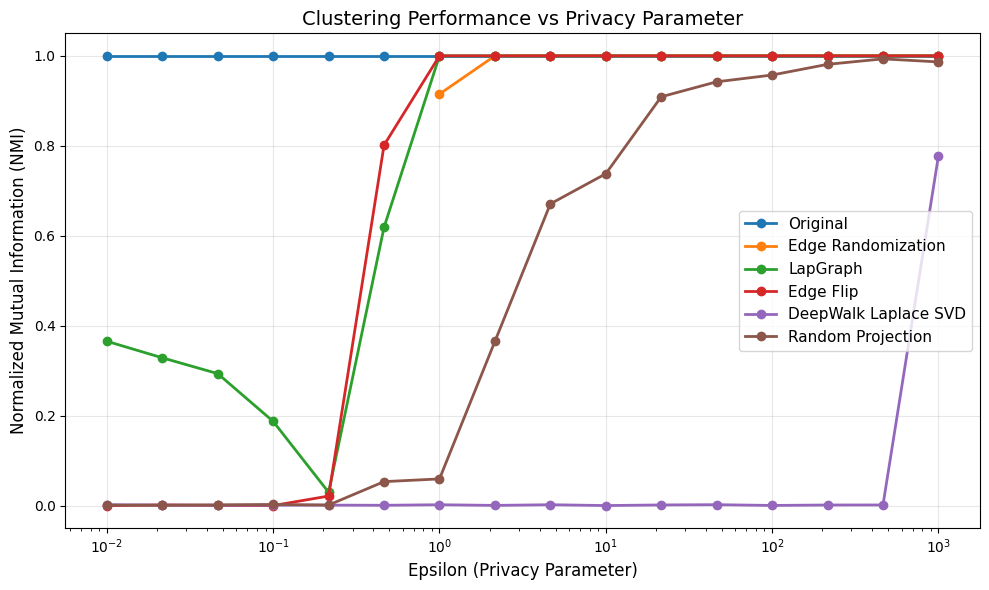

In [61]:
# Plot the results
plt.figure(figsize=(10, 6))
for method, nmi_scores in results.items():
    plt.plot(epsilon_values, nmi_scores, marker='o', label=method, linewidth=2, markersize=6)

plt.xlabel('Epsilon (Privacy Parameter)', fontsize=12)
plt.ylabel('Normalized Mutual Information (NMI)', fontsize=12)
plt.title('Clustering Performance vs Privacy Parameter', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xscale('log')  # Log scale for better visualization of epsilon values
plt.tight_layout()
plt.show()